In [4]:
import pandas as pd

In [5]:
pip install isodate

## Loading the data

In [6]:
df= pd.read_csv('merged_file.csv') #upload merged file
df.head()
a= df.shape
a

(36367, 13)

## Preprocessing

In [7]:
#dropping duplicate row
df.drop_duplicates(inplace=True)
b= df.shape
b

(36101, 13)

In [8]:
print("Number of rows dropped",a[0]-b[0])

Number of rows dropped 266


In [9]:
#checking data types of each column
df.dtypes

,0
video_id,object
channelTitle,object
title,object
description,object
tags,object
publishedAt,object
viewCount,object
likeCount,object
favoriteCount,object
commentCount,object


In [10]:
#dropping columns which. no valuable data
df.drop(columns=['caption','favoriteCount'], inplace=True)

In [11]:
#converting into appropriate data tyeps
df['viewCount'] = pd.to_numeric(df['viewCount'], errors='coerce').astype('Int64')
df['likeCount'] = pd.to_numeric(df['likeCount'], errors='coerce').astype('Int64')
df['commentCount'] = pd.to_numeric(df['commentCount'], errors='coerce').astype('Int64')
df['duration'].astype(str).str.lower().value_counts()
# Convert publishedAt to datetime
df['publishedAt'] = pd.to_datetime(df['publishedAt'], errors='coerce')

# Convert definition and caption to category
df['definition'] = df['definition'].astype('category')
df['description'] = df['description'].astype(str)
df.dtypes

,0
video_id,object
channelTitle,object
title,object
description,object
tags,object
publishedAt,"datetime64[ns, UTC]"
viewCount,Int64
likeCount,Int64
commentCount,Int64
duration,object


In [12]:
# Count null values in each column
null_counts = df.isnull().sum()
null_counts


,0
video_id,0
channelTitle,0
title,0
description,0
tags,2366
publishedAt,1
viewCount,19
likeCount,776
commentCount,363
duration,0


In [13]:
#impute reasonable values for nulls
like_median = round(df['likeCount'].median())
view_median = round(df['viewCount'].median())
comment_median = round(df['commentCount'].median())

df['likeCount'].fillna(like_median, inplace=True)
df['viewCount'].fillna(view_median, inplace=True)
df['commentCount'].fillna(comment_median, inplace=True)
df['description'].fillna("No description")

<ipython-input-13-94f4c70879b4>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['likeCount'].fillna(like_median, inplace=True)
<ipython-input-13-94f4c70879b4>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

,description
0,🍦 Got a sweet tooth? You're in the right place...
1,👗 Ready to dress to impress without buying a w...
2,🍫 Want to sneak your favorite snacks without a...
3,#SquidGameDIY 🎭 #CraftHacks ✂️ #5MinuteCrafts ...
4,🎨 Ready to level up your home decor with easy ...
...,...
36362,First time backpacking in Southeast Asia! Spen...
36363,Malaysia is one of THE most underrated countri...
36364,Road trip from NY to Vermont\n\nThanks to @yar...
36365,nan


In [14]:
import ast

def safe_parse_tags(x):
    if pd.isnull(x) or x == '':
        return []
    try:
        result = ast.literal_eval(x)
        if isinstance(result, list):
            return result
        else:
            return [str(result)]  # handle cases like a single string or word
    except Exception:
        return [str(x)]  # fallback: treat as single tag

df['tags'] = df['tags'].apply(safe_parse_tags)
df.dtypes

,0
video_id,object
channelTitle,object
title,object
description,object
tags,object
publishedAt,"datetime64[ns, UTC]"
viewCount,Int64
likeCount,Int64
commentCount,Int64
duration,object


In [15]:
# dropping row with null value because its just one
df.dropna(subset=['publishedAt'], inplace=True)


In [16]:
#verify null values
null_counts = df.isnull().sum()
null_counts

,0
video_id,0
channelTitle,0
title,0
description,0
tags,0
publishedAt,0
viewCount,0
likeCount,0
commentCount,0
duration,0


In [17]:
import isodate

# 1. Remove bad rows
df_clean = df.copy()
df_clean = df_clean[~df_clean['duration'].astype(str).str.lower().isin(['duration', 'nan'])]

# 2. Parse duration safely
def safe_parse(x):
    try:
        return isodate.parse_duration(x).total_seconds()
    except:
        return None

df_clean['duration_sec'] = df_clean['duration'].apply(safe_parse)

# 3. Drop rows where parsing failed
df_clean = df_clean[df_clean['duration_sec'].notna()]

# 4. Check what you’ve got now
print(df_clean.shape)
print(df_clean[['duration', 'duration_sec']].head())


(36100, 12)
    duration  duration_sec
0   PT1H1M6S        3666.0
1    PT1H35S        3635.0
2   PT15M31S         931.0
3      PT28S          28.0
4  PT2H3M16S        7396.0


## Feature Engineering

Adding derived columns for training

In [18]:
df_clean['title_length'] = df_clean['title'].astype(str).apply(len)
df_clean['tag_count'] = df_clean['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_clean['has_description'] = df_clean['description'].apply(lambda x: 1 if isinstance(x, str) and x.strip() else 0)
df_clean['hour'] = df_clean['publishedAt'].dt.hour

In [19]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [20]:
# Apply VADER sentiment to title
df_clean['title_sentiment'] = df_clean['title'].apply(lambda x: sid.polarity_scores(str(x))['compound'])

# Apply VADER sentiment to description
df_clean['desc_sentiment'] = df_clean['description'].apply(lambda x: sid.polarity_scores(str(x))['compound'])


One hot encoding channel names

In [21]:
channel_dummies = pd.get_dummies(df_clean['channelTitle'], prefix='channel')
df_encoded = pd.concat([df_clean, channel_dummies], axis=1)

In [22]:
# Original features
base_features = ['title_length', 'title_sentiment','has_description', 'desc_sentiment','tag_count', 'duration_sec', 'hour']

# Add one-hot channel columns
channel_features = channel_dummies.columns.tolist()

# Final features for regression
regression_features = base_features + channel_features


In [23]:
channel_ohe_columns = [col for col in df_encoded.columns if col.startswith('channel_')]


In [24]:
 df_encoded.columns

Index(['video_id', 'channelTitle', 'title', 'description', 'tags',
       'publishedAt', 'viewCount', 'likeCount', 'commentCount', 'duration',
       'definition', 'duration_sec', 'title_length', 'tag_count',
       'has_description', 'hour', 'title_sentiment', 'desc_sentiment',
       'channel_5-Minute Crafts', 'channel_Avery Smith | Data Analyst',
       'channel_BRIGHT SIDE', 'channel_BuzzFeedVideo',
       'channel_Darshil Parmar', 'channel_Grate and Garnish', 'channel_Tasty',
       'channel_Tech With Lucy', 'channel_The Fitness Marshall',
       'channel_Thu Vu', 'channel_Tierra', 'channel_Tina Yong',
       'channel_Tressuni', 'channel_Vicky Zhao [BEEAMP]', 'channel_jayzern'],
      dtype='object')

##Exploratory Data Analysis


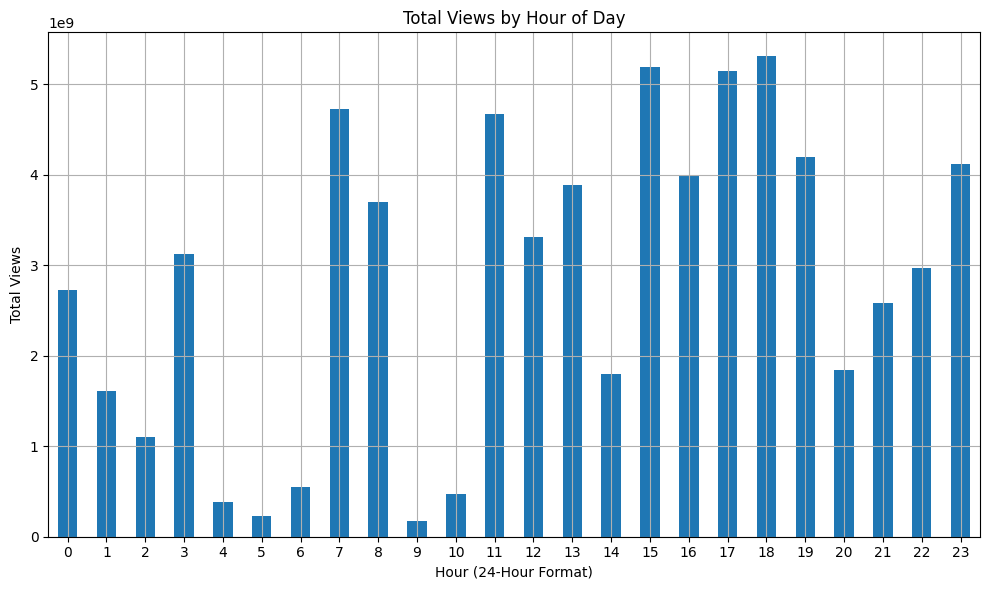

In [25]:
import matplotlib.pyplot as plt

# Group by hour and sum views
views_by_hour = df_encoded.groupby('hour')['viewCount'].sum()

# Plot
views_by_hour.plot(kind='bar', figsize=(10,6))
plt.title("Total Views by Hour of Day")
plt.xlabel("Hour (24-Hour Format)")
plt.ylabel("Total Views")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

A bar chart of total views by upload hour showed that videos posted between 15:00 and 19:00 received the highest views, indicating peak audience activity. In contrast, uploads between 4:00 and 6:00 had the lowest engagement. These insights highlight the impact of upload timing on video performance.

<Figure size 1200x600 with 0 Axes>

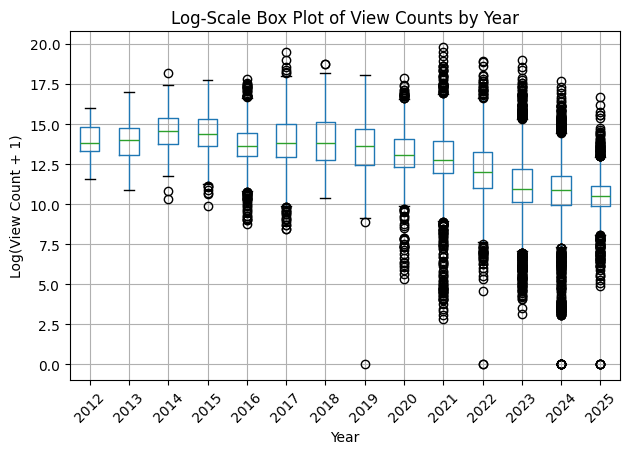

In [26]:
import numpy as np

df_encoded['log_viewCount'] = np.log1p(df_encoded['viewCount'])  # log(1 + x) to handle zeros
df_encoded['year'] = df_encoded['publishedAt'].dt.year
plt.figure(figsize=(12, 6))
df_encoded.boxplot(column='log_viewCount', by='year')
plt.title("Log-Scale Box Plot of View Counts by Year")
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Log(View Count + 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



This trend indicates a peak in viewership during 2017–2019, particularly in 2018. A significant decline is noticeable post-2020, possibly reflecting shifts in content consumption behavior, platform changes, or data availability. Seasonal variations are visible, with certain years showing spikes during mid and end of the year.

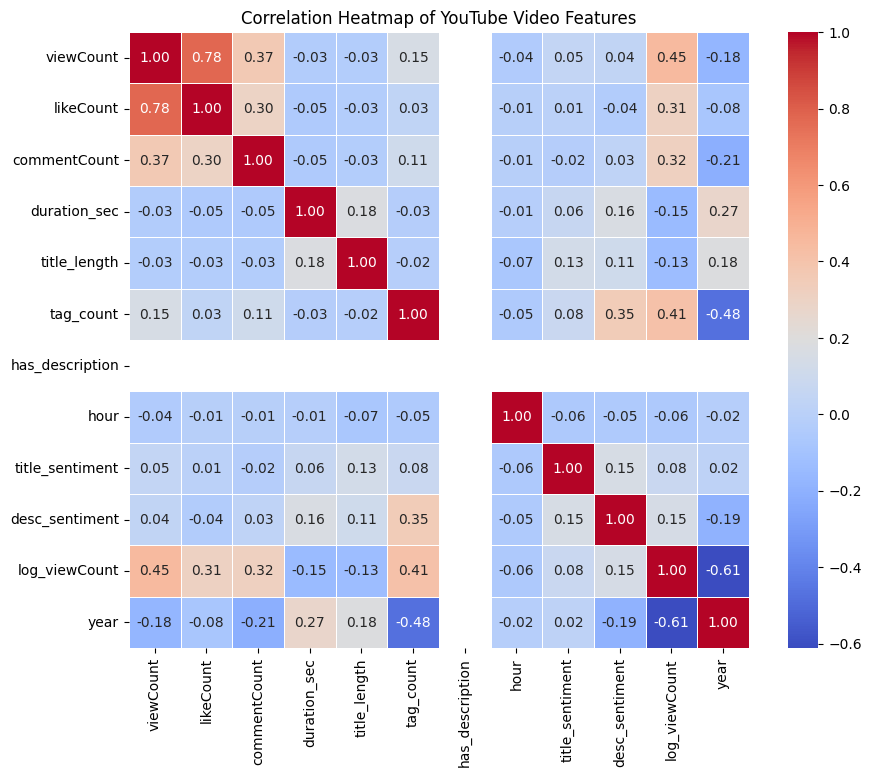

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt



# Select only numeric columns
numeric_df = df_encoded.select_dtypes(include='number')

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of YouTube Video Features')
plt.show()


The correlation heatmap showed that viewCount is strongly correlated with likeCount (0.78) and log_viewCount (0.45), confirming likes as a key popularity signal. Moderate correlations with tag_count and desc_sentiment suggest metadata and sentiment also impact visibility. A negative correlation with year (–0.61) supports the decline in views for recent uploads.



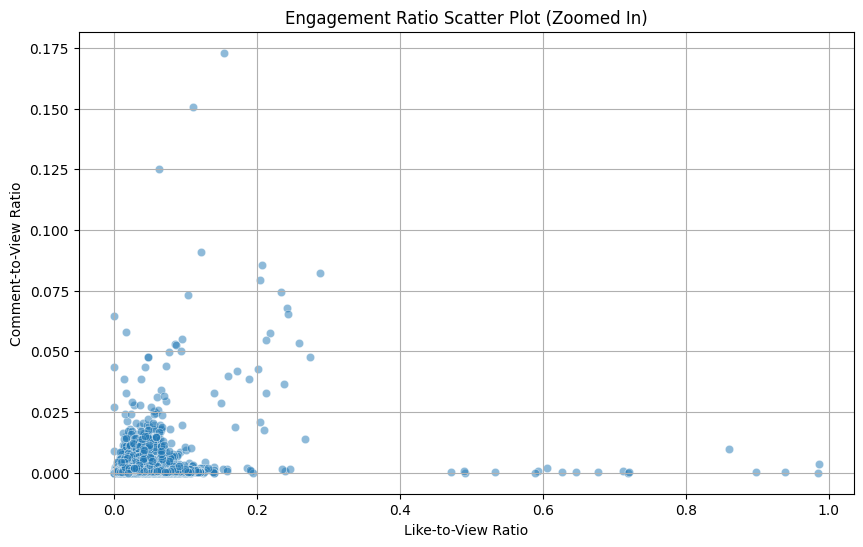

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Recalculate if needed
df_encoded['like_ratio'] = df_encoded['likeCount'] / df_encoded['viewCount']
df_encoded['comment_ratio'] = df_encoded['commentCount'] / df_encoded['viewCount']

# Clean up
df_engage = df_encoded[['like_ratio', 'comment_ratio']].replace([np.inf, -np.inf], np.nan).dropna()

# OPTIONAL: filter to ignore extreme outliers (you can tweak limits as needed)
filtered = df_engage[(df_engage['like_ratio'] < 1) & (df_engage['comment_ratio'] < 0.2)]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered, x='like_ratio', y='comment_ratio', alpha=0.5)
plt.title("Engagement Ratio Scatter Plot (Zoomed In)")
plt.xlabel("Like-to-View Ratio")
plt.ylabel("Comment-to-View Ratio")
plt.grid(True)
plt.show()


The scatter plot of like-to-view vs comment-to-view ratios (excluding outliers) showed most videos have low but consistent engagement, with like ratios below 0.2 and comment ratios below 0.05. A few outliers with high comment ratios and lower like ratios suggest conversational or controversial content. This distinction helps identify active engagement and informs content strategy or future classification.


## Modelling

### Regression

In [29]:
from sklearn.model_selection import train_test_split
#  regression features
#  'title_length', 'title_sentiment','has_description', 'desc_sentiment','tag_count', 'duration_sec', 'hour','title_sentiment','desc_sentiment' + ohe columns
X = df_encoded[regression_features]
y = df_encoded['log_viewCount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [51]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    'RandomForest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100],
            'regressor__max_depth': [None, 10],
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'regressor__n_estimators': [100],
            'regressor__learning_rate': [0.05, 0.1],
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42, objective='reg:squarederror'),
        'params': {
            'regressor__n_estimators': [100],
            'regressor__max_depth': [3, 5],
        }
    }
}


In [52]:
cv_results = []

for name, config in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', config['model'])
    ])

    grid = GridSearchCV(
        pipeline,
        config['params'],
        cv=5,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)

    cv_results.append({
        'model': name,
        'best_params': grid.best_params_,
        'best_cv_mse': -grid.best_score_
    })

# Display the results
cv_results_df = pd.DataFrame(cv_results).sort_values(by='best_cv_mse')
print(cv_results_df)


              model                                        best_params  \
2           XGBoost  {'regressor__max_depth': 5, 'regressor__n_esti...   
0      RandomForest  {'regressor__max_depth': None, 'regressor__n_e...   
1  GradientBoosting  {'regressor__learning_rate': 0.1, 'regressor__...   

   best_cv_mse  
2     1.829577  
0     1.830091  
1     2.210156  


#### Predictive Validity

In [53]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import joblib

best_model = grid.best_estimator_


# Predict on test data
y_pred = best_model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 Final Model Performance on Test Set:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


📊 Final Model Performance on Test Set:
R² Score: 0.5735
MSE: 1.8057
RMSE: 1.3437


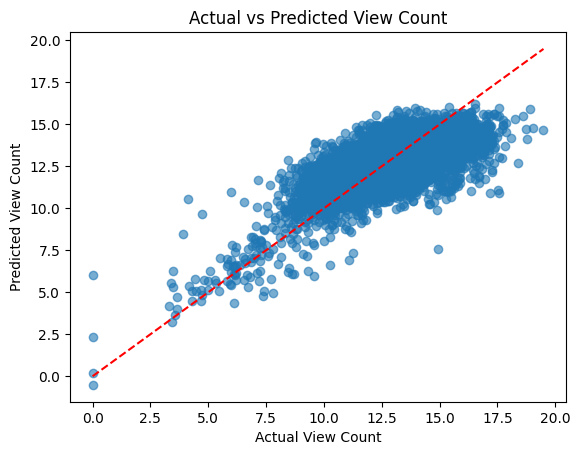

In [54]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual View Count")
plt.ylabel("Predicted View Count")
plt.title("Actual vs Predicted View Count")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.show()

The scatter plot of actual vs predicted log view counts shows strong alignment, with most points clustering near the diagonal—indicating accurate predictions. Some variance appears at high-view outliers, but overall, the model effectively captures key patterns, validating its use for estimating video popularity.


### Clustering Algorithms

In [59]:
features = ['title_length', 'title_sentiment','has_description', 'desc_sentiment','tag_count', 'duration_sec', 'hour' , 'log_viewCount']
X_unsupervised = df_encoded[features]


In [60]:
X_unsupervised.shape


(36100, 8)

In [61]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)  # or however many clusters you want
df_encoded['kmeans_cluster'] = kmeans.fit_predict(X_unsupervised)


In [37]:
from sklearn.cluster import AgglomerativeClustering
agglo = AgglomerativeClustering(n_clusters=4)
df_encoded['agglo_cluster'] = agglo.fit_predict(X_unsupervised)


In [38]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=42)
df_encoded['gmm_cluster'] = gmm.fit_predict(X_unsupervised)


In [39]:
from sklearn.metrics import silhouette_score

score_kmeans = silhouette_score(X_unsupervised, df_encoded['kmeans_cluster'])
score_gmm = silhouette_score(X_unsupervised, df_encoded['gmm_cluster'])
score_agglo = silhouette_score(X_unsupervised, df_encoded['agglo_cluster'])


In [40]:
print(f"KMeans Silhouette Score: {score_kmeans:.4f}")
print(f"Gaussian Mixture Silhouette Score: {score_gmm:.4f}")
print(f"Agglomerative Clustering Silhouette Score: {score_agglo:.4f}")

KMeans Silhouette Score: 0.8767
Gaussian Mixture Silhouette Score: 0.2110
Agglomerative Clustering Silhouette Score: 0.8684


After evaluating multiple clustering algorithms using the Silhouette Score as a performance metric, I chose KMeans with k = 4 as the final clustering method. KMeans achieved the highest Silhouette Score of 0.8767, indicating well-separated and cohesive clusters. In comparison, Agglomerative Clustering had a slightly lower score of 0.8684, while Gaussian Mixture performed significantly worse with a score of 0.2110. Given KMeans' strong performance and clear cluster definition, it was the most suitable choice for this analysis.

In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import matplotlib.cm as cm

def silhouette_plot(X, cluster_range=[2, 3, 4], method='kmeans'):
    fig, axs = plt.subplots(1, len(cluster_range), figsize=(5 * len(cluster_range), 6))

    for i, n_clusters in enumerate(cluster_range):
        ax = axs[i]

        model = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = model.fit_predict(X)

        silhouette_avg = silhouette_score(X, cluster_labels)
        sample_silhouette_values = silhouette_samples(X, cluster_labels)

        y_lower = 10
        for j in range(n_clusters):
            jth_silhouette_vals = sample_silhouette_values[cluster_labels == j]
            jth_silhouette_vals.sort()

            size_j_cluster = jth_silhouette_vals.shape[0]
            y_upper = y_lower + size_j_cluster

            color = cm.nipy_spectral(float(j) / n_clusters)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, jth_silhouette_vals,
                             facecolor=color, edgecolor=color, alpha=0.7)
            ax.text(-0.05, y_lower + 0.5 * size_j_cluster, str(j))
            y_lower = y_upper + 10

        ax.set_title(f"{method.upper()} | $n$ = {n_clusters}")
        ax.set_xlabel("Silhouette")
        ax.set_ylabel("Cluster")
        ax.axvline(x=silhouette_avg, color="black", linestyle="--")
        ax.set_yticks([])
        ax.set_xlim([-0.1, 1])
        ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    plt.tight_layout()
    plt.show()


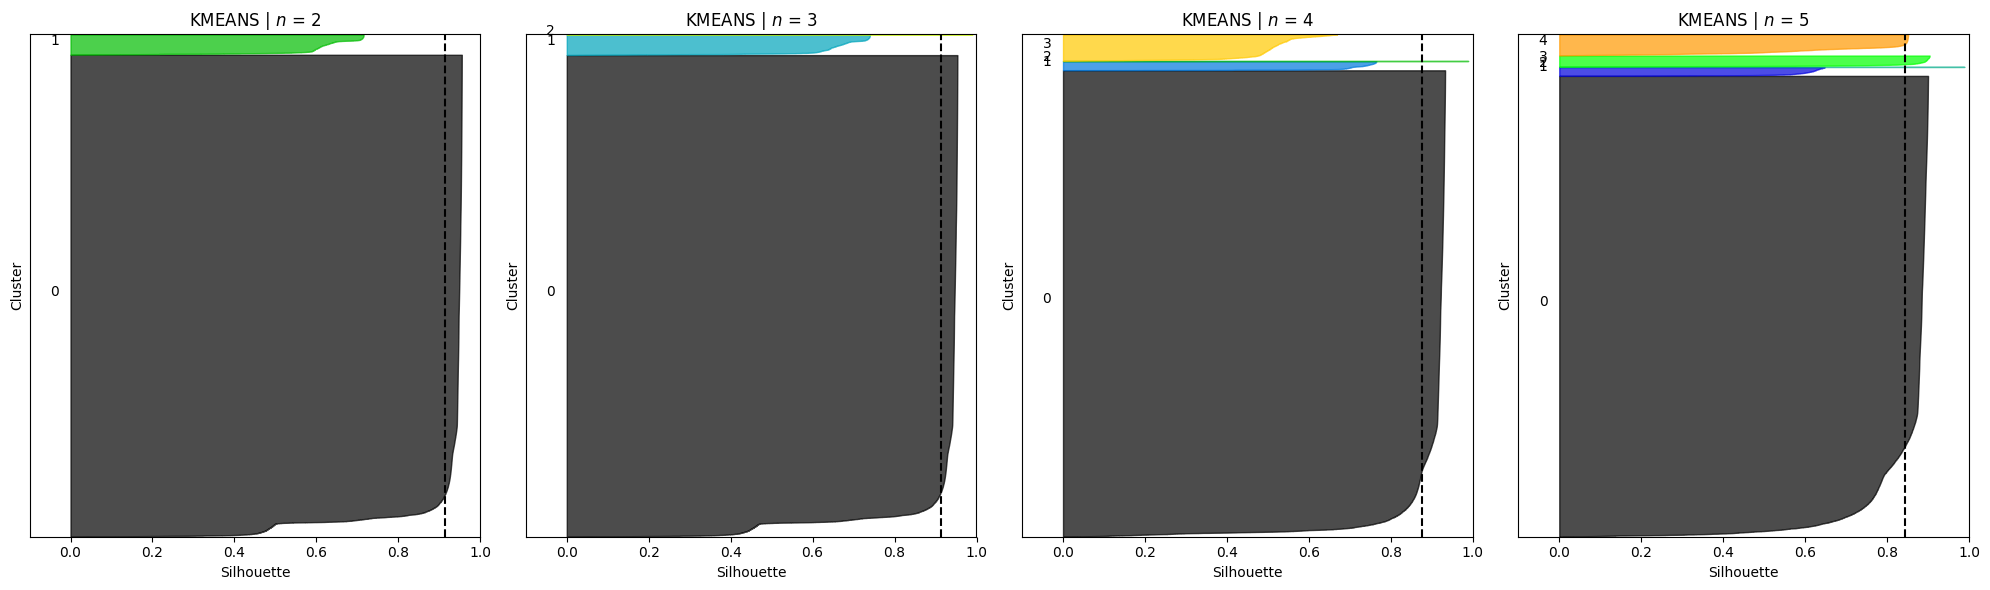

In [42]:
# For the best clustering Algorithm -KMeans:
silhouette_plot(X_unsupervised, cluster_range=[2, 3, 4, 5], method='kmeans')



In [62]:
#k means whihc k=4 has better clustering ; 5 did not divide the data better
cluster_names = {
    0: "Low",
    1: "Medium",
    2: "High",
    3: "Viral"
}
df_encoded['cluster_name'] = df_encoded['kmeans_cluster'].map(cluster_names)


In [64]:
def get_cluster_to_label_map_4(kmeans_model):
    centers = kmeans_model.cluster_centers_[:, 6]  #
    sorted_indices = centers.argsort()
    labels = ['Low', 'Medium', 'High', 'Viral']
    return {cluster_idx: labels[i] for i, cluster_idx in enumerate(sorted_indices)}


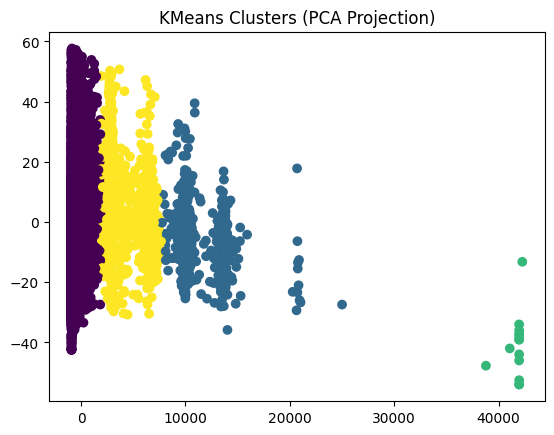

In [65]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=2).fit_transform(df_encoded[features])
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_encoded['kmeans_cluster'], cmap='viridis')
plt.title("KMeans Clusters (PCA Projection)")
plt.show()


#### Predictive validity

In [66]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.utils import resample
import numpy as np

def cluster_stability_kmeans(X, n_clusters=4, n_iter=10, sample_fraction=0.8, random_state=42):
    """
    Estimate cluster stability for your existing KMeans setup on X.

    Parameters:
    - X: DataFrame or array of your features (e.g., X_unsupervised)
    - n_clusters: Number of clusters
    - n_iter: How many times to run stability check
    - sample_fraction: How much data to sample each time
    - random_state: For reproducibility

    Returns:
    - ARI scores list
    - Mean ARI
    """
    clusterings = []
    rng = np.random.RandomState(random_state)
    seeds = rng.randint(0, 10000, size=n_iter)

    for seed in seeds:
        # Subsample data
        X_sample = resample(X, replace=False, n_samples=int(sample_fraction * len(X)), random_state=seed)
        sample_idx = X_sample.index if hasattr(X_sample, 'index') else np.arange(len(X_sample))

        # Cluster it
        kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
        labels = kmeans.fit_predict(X_sample)

        clusterings.append((sample_idx, labels))

    # Compute ARIs between all clusterings
    ari_scores = []
    for i in range(len(clusterings)):
        for j in range(i + 1, len(clusterings)):
            idx1, labels1 = clusterings[i]
            idx2, labels2 = clusterings[j]

            common_idx = np.intersect1d(idx1, idx2)
            if len(common_idx) < 2:
                continue

            map1 = {idx: label for idx, label in zip(idx1, labels1)}
            map2 = {idx: label for idx, label in zip(idx2, labels2)}

            labels1_common = [map1[idx] for idx in common_idx]
            labels2_common = [map2[idx] for idx in common_idx]

            ari = adjusted_rand_score(labels1_common, labels2_common)
            ari_scores.append(ari)

    return ari_scores, np.mean(ari_scores)


In [67]:
ari_scores, mean_ari = cluster_stability_kmeans(X_unsupervised, n_clusters=4)
print(f"Cluster stability (Mean ARI): {mean_ari:.3f}")


Cluster stability (Mean ARI): 0.693


To assess the stability of the clustering results, I calculated the Mean Adjusted Rand Index (ARI), which measures the similarity between different runs of the clustering algorithm under slight perturbations. The KMeans model with k = 4 achieved a Mean ARI of 0.693, indicating a high level of consistency in the clustering assignments. This suggests that the model produces stable and reliable clusters, reinforcing the robustness of the chosen clustering approach.

# Final pipeline using Gradio for interface

In [48]:
!pip install Gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.3 MB/s eta 0:00:00


In [49]:
#Sample data to fill the form
sample_input = {
    'title': "5 Hacks to Save Your Day!",
    'tags_count': 10,
    'description': "These are some amazing life hacks that will surprise you.",
    'duration': "PT5M30S",
    'channel_name': "5-Minute Crafts",
    'hour':12
}



In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import isodate
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize sentiment analyzer
sid = SentimentIntensityAnalyzer()

# Utility to map cluster to label (4-class version)
def get_cluster_to_label_map_4(kmeans_model):
    centers = kmeans_model.cluster_centers_[:, 6]
    sorted_indices = centers.argsort()
    labels = [ 'Low', 'Medium', 'High','Viral']
    return {cluster_idx: labels[i] for i, cluster_idx in enumerate(sorted_indices)}

original_channels = [
    '5mincrafts', 'Bright_side', 'Buzzfeed', 'Tasty_6000',
    'Thu_vu', 'averysmith', 'grateandgarnish5877', 'thefitnessmarshall',
    'tina_yong', 'VickyZhaoBEEAMP', 'TechwithLucy', 'tressuni',
    'itgirltierra', 'DarshilParmar', 'jayzern'
]

# Prediction function
def predict_popularity_gradio(title, tags_count, description, duration,hour, channel_name):
    print("called")

    # Step 1: Manual feature engineering

    title_length = len(title)
    has_description = int(bool(description))
    title_senti = sid.polarity_scores(title)['compound']
    desc_senti = sid.polarity_scores(description)['compound']

    try:
        duration_sec = isodate.parse_duration(duration).total_seconds()
    except:
        duration_sec = 0

    # Step 2: One-hot encode channel name
    channel_ohe = pd.DataFrame(columns=channel_ohe_columns)
    for col in channel_ohe_columns:
        channel_ohe[col] = [1 if col == f'channel_{channel_name}' else 0]

    # Step 3: Build full feature set
    features = pd.DataFrame([{
        'title_length': title_length,
        'title_sentiment': title_senti,
        'has_description': has_description,
        'desc_sentiment': desc_senti,
        'tag_count': tags_count,
        'duration_sec': duration_sec,
        'hour': hour
    }])
    regression_features = features.columns.tolist() + channel_ohe_columns

    sample = pd.concat([features, channel_ohe], axis=1)
    sample = sample[regression_features]

    # match training features

    print("🧪 [DEBUG] Sample input for model:\n", sample.head())
    print("🧪 [DEBUG] Regression feature shape:", sample.shape)
    # Step 4: Predict log view count
    log_view_pred = best_model.predict(sample)[0]
    view_pred = int(np.expm1(log_view_pred))
    print("🧪 [DEBUG] Predicted log view count:", log_view_pred)
    print("🧪 [DEBUG] Predicted actual view count:", view_pred)

    # Step 5: Cluster prediction
    cluster_input = pd.DataFrame([{
        'title_length': title_length,
        'title_sentiment': title_senti,
        'has_description': has_description,
        'desc_sentiment': desc_senti,
        'tag_count': tags_count,
        'duration_sec': duration_sec,
        'hour': hour,
        'log_viewCount': log_view_pred
    }])
    cluster_label = kmeans.predict(cluster_input)[0]
    cluster_to_label = get_cluster_to_label_map_4(kmeans)
    popularity_bin = cluster_to_label[cluster_label]
    print("🧪 [DEBUG] Cluster label:", cluster_label)
    print("🧪 [DEBUG] Popularity bin:", popularity_bin)

    result= f"📈 Predicted View Count: {view_pred:,}\n📊 Popularity Bin: {popularity_bin}"
    return result


# Gradio UI
demo = gr.Interface(
    fn=predict_popularity_gradio,
    inputs=[
        gr.Textbox(label="Video Title"),
        gr.Number(label="Tag Count", value=10),
        gr.Textbox(label="Description"),
        gr.Textbox(label="Duration (ISO format, e.g. PT5M30S)"),
        gr.Number(label="Hour of Upload", value=12),
        gr.Textbox(label="Channel Name")
    ],
    outputs="text",
    title="🎥 YouTube Popularity Predictor",
    description="Enter your video's details to predict its view count and popularity category (Low to Viral)."
)

demo.launch(debug=True)


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a928bab143ad5056a2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


called
🧪 [DEBUG] Sample input for model:
    title_length  title_sentiment  has_description  desc_sentiment  tag_count  \
0            25           0.5411                1          0.7096         10   

   duration_sec  hour  channel_5-Minute Crafts  \
0         330.0    12                        0   

   channel_Avery Smith | Data Analyst  channel_BRIGHT SIDE  ...  \
0                                   0                    0  ...   

   channel_Grate and Garnish  channel_Tasty  channel_Tech With Lucy  \
0                          0              0                       0   

   channel_The Fitness Marshall  channel_Thu Vu  channel_Tierra  \
0                             0               0               0   

   channel_Tina Yong  channel_Tressuni  channel_Vicky Zhao [BEEAMP]  \
0                  0                 0                            0   

   channel_jayzern  
0                0  

[1 rows x 22 columns]
🧪 [DEBUG] Regression feature shape: (1, 22)
🧪 [DEBUG] Predicted log view co